In [2]:
import scipy as sc
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
# import pandas as pd
from scipy.integrate import quad
from scipy.optimize import curve_fit

matplotlib.rcParams.update(
        {"font.family": "STIXGeneral",
         "xtick.labelsize": 20,
         "xtick.direction": "in",
         "xtick.major.pad": 8,
         "xtick.top": True,
         "ytick.labelsize": 20,
         "ytick.direction": "in",
         "ytick.right": True,
         "axes.labelsize": 20,
         "axes.labelpad": 10,
         "axes.grid": True
    }
)

Raw data

The total counts: 256.0


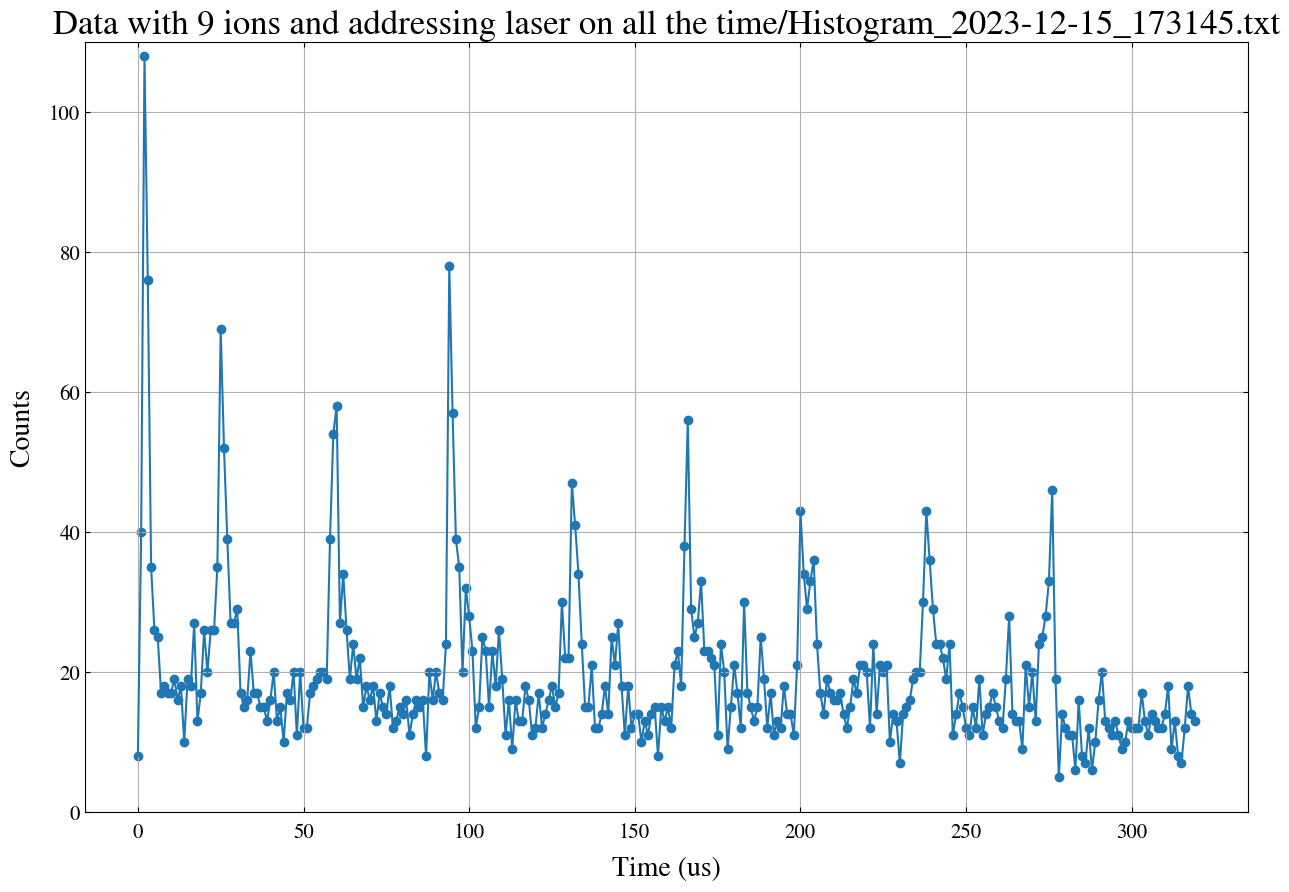

In [16]:
path = "C:/Users/Bingran You/Downloads"
file_name = "/Histogram_2023-12-15_173145.txt"
raw_data = np.loadtxt(path+file_name, \
                        delimiter='\t', dtype='str')
data = np.array(raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")

length = len(raw_data)

start_point = 290 #first five points are not good
end_point = start_point + 20

time_bins = data[0, :] / 1e6
counts = data[1, :]
background_counts = (np.sum(counts[0:start_point])) / start_point
# counts -= background_counts
counts_sum = np.sum(counts[start_point:end_point])
title = "Data with 9 ions and addressing laser on all the time" + file_name

print('The total counts:', counts_sum)

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.plot(time_bins, counts, c='C0')
plt.scatter(time_bins, counts, c='C0')
# plt.axvline(time_bins[start_point], color='r')
# plt.axvline(time_bins[end_point], color='r')
plt.title(title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(counts) + 2)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig('./'+file_name+' _data.jpg')
plt.show()

Binning

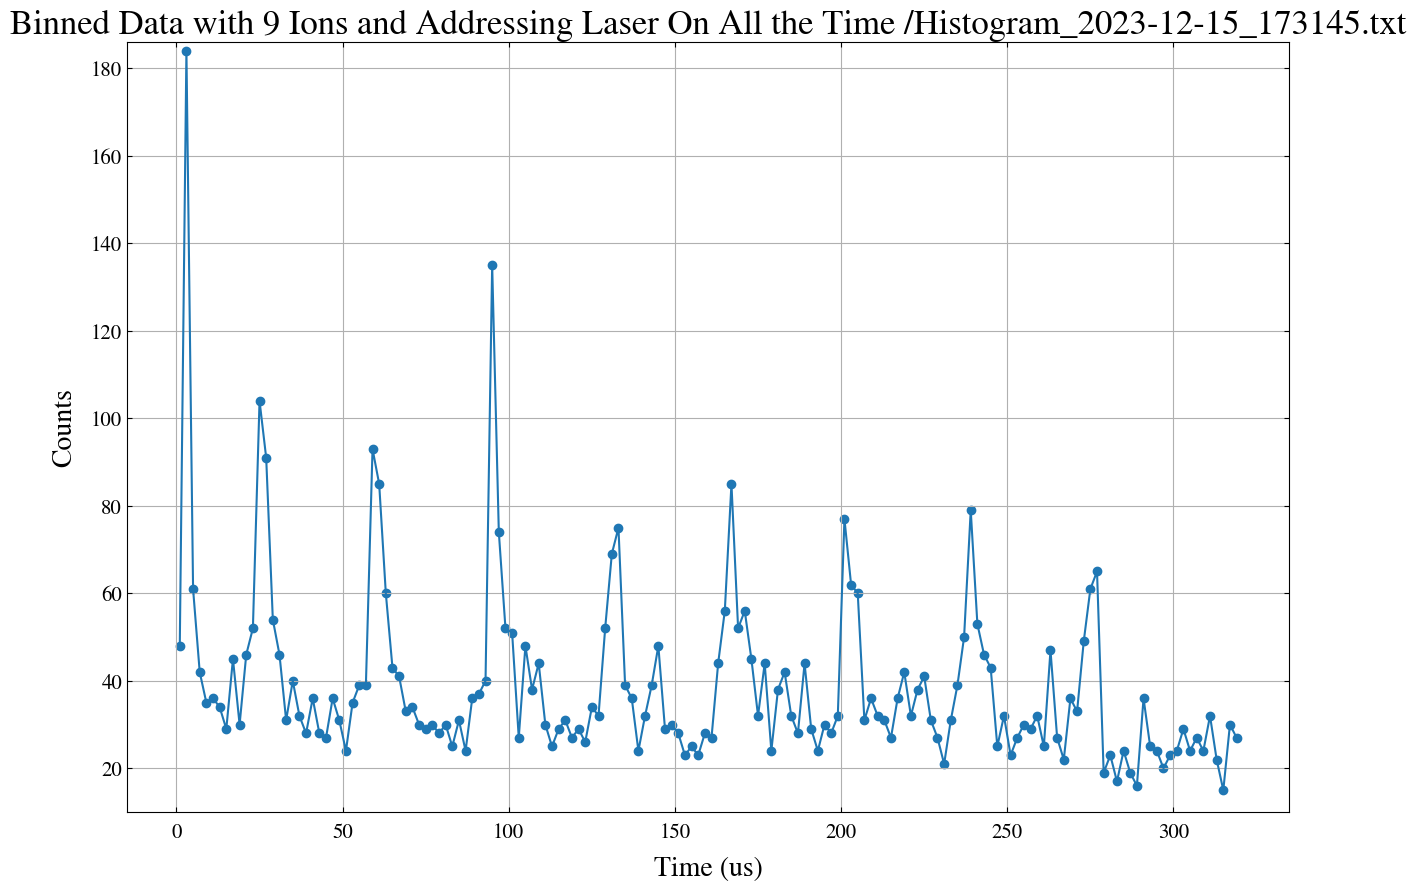

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Load data
path = "C:/Users/Bingran You/Downloads"
file_name = "/Histogram_2023-12-15_173145.txt"
raw_data = np.loadtxt(path+file_name, delimiter='\t', dtype='str')
data = np.array(raw_data[1:]).astype(dtype="f").transpose()

# Existing processing
length = len(raw_data)
start_point = 290
end_point = start_point + 20
time_bins = data[0, :] / 1e6
counts = data[1, :]
background_counts = (np.sum(counts[0:start_point])) / start_point

# Binning
bin_width = 2  # Define bin width in microseconds (adjust as needed)
bin_edges = np.arange(min(time_bins), max(time_bins) + bin_width, bin_width)
binned_counts = np.zeros(len(bin_edges) - 1)
for i in range(1, len(bin_edges)):
    bin_filter = (time_bins >= bin_edges[i-1]) & (time_bins < bin_edges[i])
    binned_counts[i-1] = np.sum(counts[bin_filter])

# Binned Time for Plotting (Midpoints of Bins)
binned_time = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plotting
title = "Binned Data with 9 Ions and Addressing Laser On All the Time " + file_name
plt.figure(figsize=(15, 10))
plt.plot(binned_time, binned_counts, c='C0')
plt.scatter(binned_time, binned_counts, c='C0')
plt.title(title, fontdict={'family': 'STIXGeneral', 'size': 25})
plt.xlabel('Time (us)', fontdict={'family': 'STIXGeneral', 'size': 20})
plt.ylabel('Counts', fontdict={'family': 'STIXGeneral', 'size': 20})
plt.ylim(10, np.max(binned_counts) + 2)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig('./'+file_name+' _binned_data.jpg')
plt.show()

Peak finding

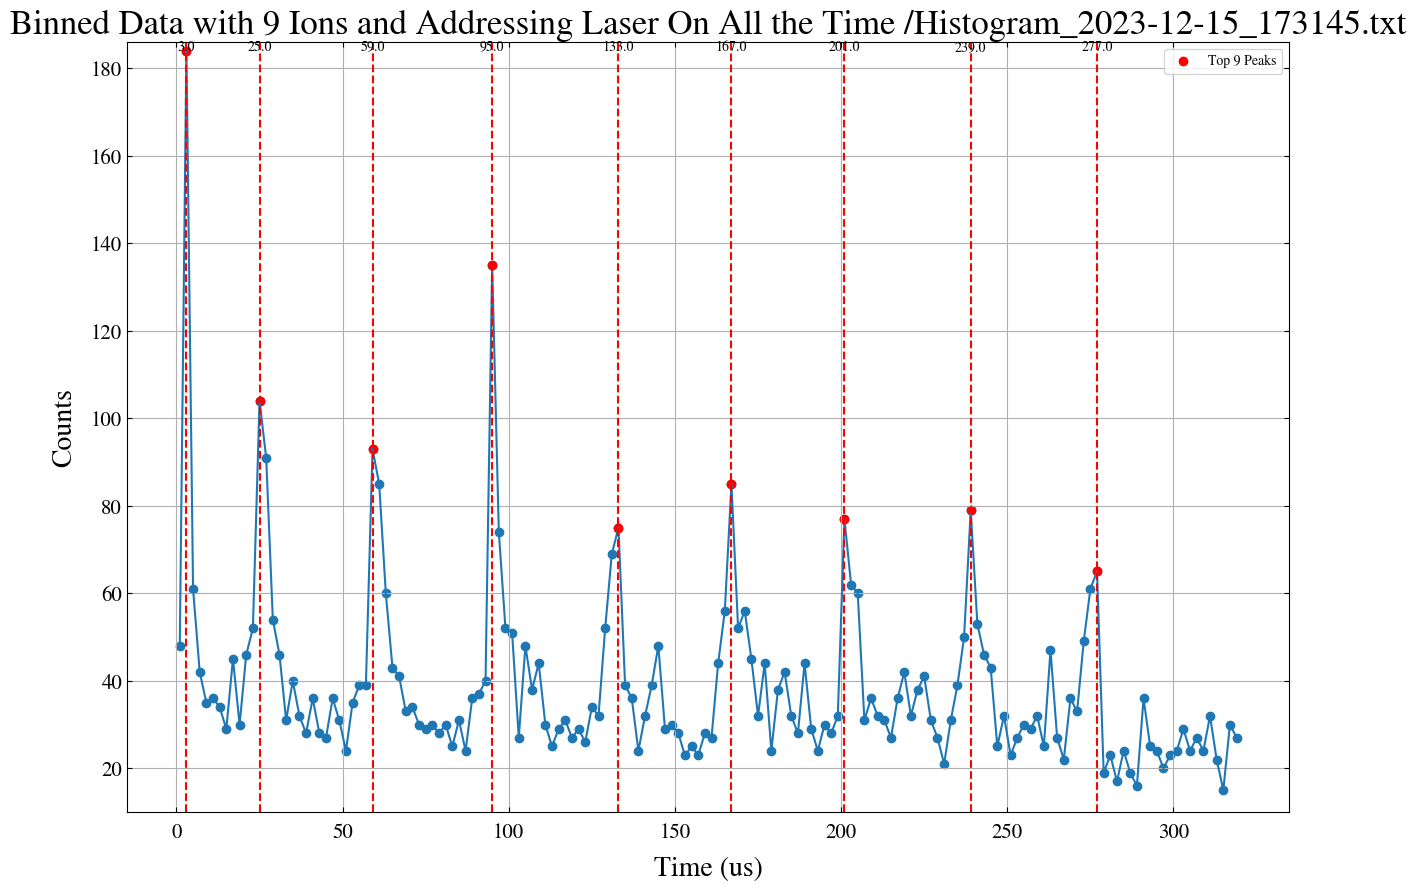

In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_prominences

# Load data
path = "C:/Users/Bingran You/Downloads"
file_name = "/Histogram_2023-12-15_173145.txt"
raw_data = np.loadtxt(path+file_name, delimiter='\t', dtype='str')
data = np.array(raw_data[1:]).astype(dtype="f").transpose()

# Existing processing
time_bins = data[0, :] / 1e6
counts = data[1, :]
start_point = 290
background_counts = (np.sum(counts[0:start_point])) / start_point

# Binning
bin_width = 2  # Define bin width in microseconds
bin_edges = np.arange(min(time_bins), max(time_bins) + bin_width, bin_width)
binned_counts = np.zeros(len(bin_edges) - 1)
for i in range(1, len(bin_edges)):
    bin_filter = (time_bins >= bin_edges[i-1]) & (time_bins < bin_edges[i])
    binned_counts[i-1] = np.sum(counts[bin_filter])

# Binned Time for Plotting (Midpoints of Bins)
binned_time = (bin_edges[:-1] + bin_edges[1:]) / 2

# Peak Detection
peaks, _ = find_peaks(binned_counts)
prominences = peak_prominences(binned_counts, peaks)[0]

# Selecting the 9 Largest Peaks
largest_peaks = peaks[np.argsort(prominences)[-9:]]

# Plotting
title = "Binned Data with 9 Ions and Addressing Laser On All the Time " + file_name
plt.figure(figsize=(15, 10))
plt.plot(binned_time, binned_counts, c='C0')
plt.scatter(binned_time, binned_counts, c='C0')

# Marking the Peaks with Red Dashed Lines
for peak in largest_peaks:
    plt.axvline(x=binned_time[peak], color='red', linestyle='--')
    plt.text(binned_time[peak], np.max(binned_counts), f'{binned_time[peak]}', color='black', ha='center')

plt.scatter(binned_time[largest_peaks], binned_counts[largest_peaks], c='red', label='Top 9 Peaks')
plt.title(title, fontdict={'family': 'STIXGeneral', 'size': 25})
plt.xlabel('Time (us)', fontdict={'family': 'STIXGeneral', 'size': 20})
plt.ylabel('Counts', fontdict={'family': 'STIXGeneral', 'size': 20})
plt.ylim(10, np.max(binned_counts) + 2)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.legend()
plt.grid(True)
plt.savefig('./'+file_name+' _binned_data_top_9_peaks.jpg')
plt.show()

Do the same to pulsed generation

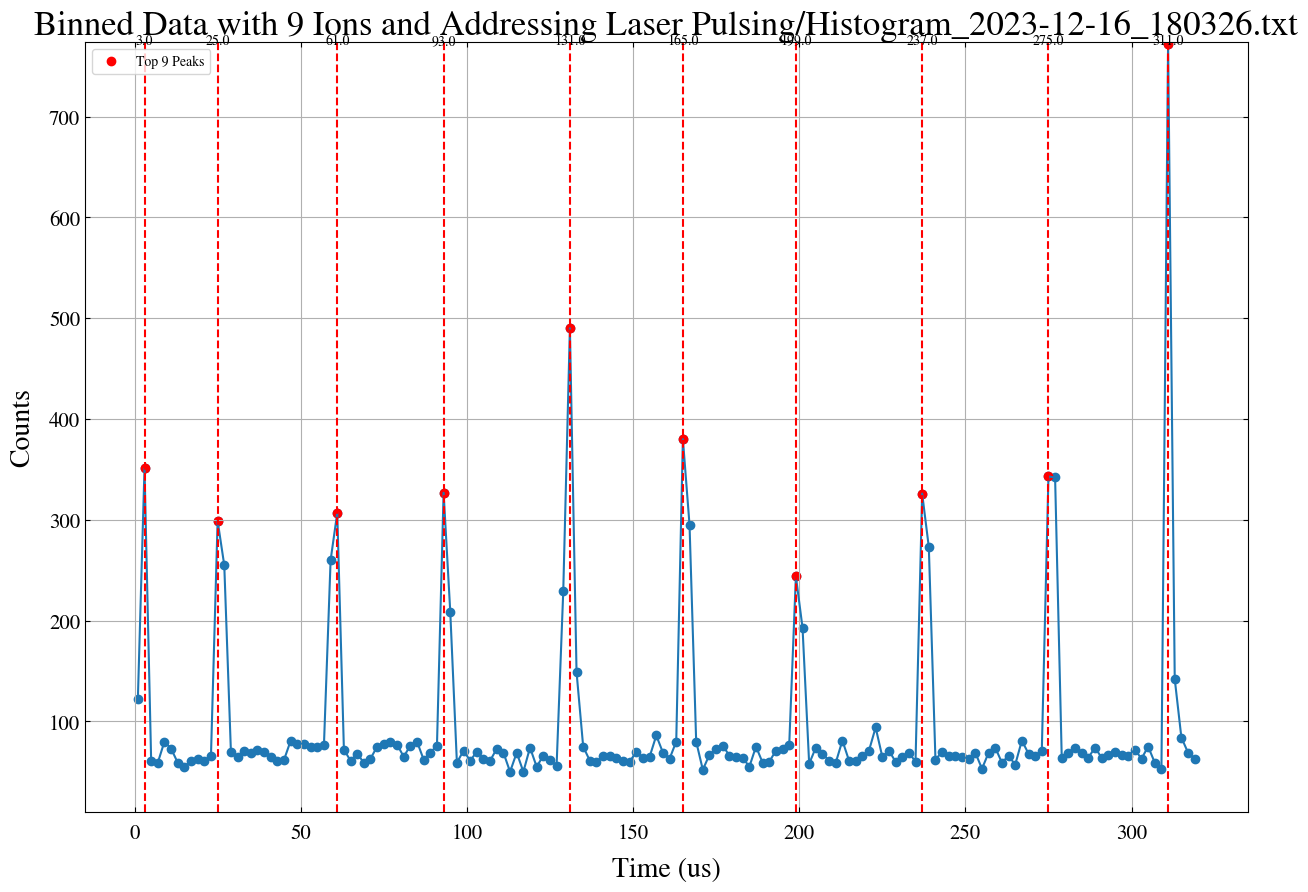

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, peak_prominences

# Load data
path = "C:/Users/Bingran You/Downloads"
file_name = "/Histogram_2023-12-16_180326.txt"
raw_data = np.loadtxt(path+file_name, delimiter='\t', dtype='str')
data = np.array(raw_data[1:]).astype(dtype="f").transpose()

# Existing processing
time_bins = data[0, :] / 1e6
counts = data[1, :]
start_point = 290
background_counts = (np.sum(counts[0:start_point])) / start_point

# Binning
bin_width = 2  # Define bin width in microseconds
bin_edges = np.arange(min(time_bins), max(time_bins) + bin_width, bin_width)
binned_counts = np.zeros(len(bin_edges) - 1)
for i in range(1, len(bin_edges)):
    bin_filter = (time_bins >= bin_edges[i-1]) & (time_bins < bin_edges[i])
    binned_counts[i-1] = np.sum(counts[bin_filter])

# Binned Time for Plotting (Midpoints of Bins)
binned_time = (bin_edges[:-1] + bin_edges[1:]) / 2

# Peak Detection
peaks, _ = find_peaks(binned_counts)
prominences = peak_prominences(binned_counts, peaks)[0]

# Selecting the 9 Largest Peaks
largest_peaks = peaks[np.argsort(prominences)[-10:]]

# Plotting
title = "Binned Data with 9 Ions and Addressing Laser Pulsing" + file_name
plt.figure(figsize=(15, 10))
plt.plot(binned_time, binned_counts, c='C0')
plt.scatter(binned_time, binned_counts, c='C0')

# Marking the Peaks with Red Dashed Lines
for peak in largest_peaks:
    plt.axvline(x=binned_time[peak], color='red', linestyle='--')
    plt.text(binned_time[peak], np.max(binned_counts), f'{binned_time[peak]}', color='black', ha='center')

plt.scatter(binned_time[largest_peaks], binned_counts[largest_peaks], c='red', label='Top 9 Peaks')
plt.title(title, fontdict={'family': 'STIXGeneral', 'size': 25})
plt.xlabel('Time (us)', fontdict={'family': 'STIXGeneral', 'size': 20})
plt.ylabel('Counts', fontdict={'family': 'STIXGeneral', 'size': 20})
plt.ylim(10, np.max(binned_counts) + 2)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.legend()
plt.grid(True)
plt.savefig('./'+file_name+' _binned_data_top_9_peaks.jpg')
plt.show()

In [3]:
path = "G:/Google_Drive/Experimental_Data/Multiplexing/TimeTagger_Data"
file_name = "/Histogram_2023-11-30_190251_Addressing laser_71.6uW after fiber.txt"
raw_data = np.loadtxt(path+file_name, \
                        delimiter='\t', dtype='str')
data = np.array(raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")

length = len(raw_data)

start_point = 120 + 10 #first five points are not good
end_point = int(length // 2.1) + 10

time_bins = data[0, :] / 1e6
counts = data[1, :]
background_counts = (np.sum(counts[0:start_point])) / start_point
counts -= background_counts
counts_sum = np.sum(counts[start_point:end_point])
title = "Data with 3 ions and global laser" + file_name

print('The total counts:', counts_sum)

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(time_bins, counts, c='C0')
plt.axvline(time_bins[start_point], color='r')
plt.axvline(time_bins[end_point], color='r')
plt.title(title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(counts) + 2)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig('./'+file_name+' _data.jpg')
plt.show()

OSError: G:/Google_Drive/Experimental_Data/Multiplexing/TimeTagger_Data/Histogram_2023-11-30_190251_Addressing laser_71.6uW after fiber.txt not found.

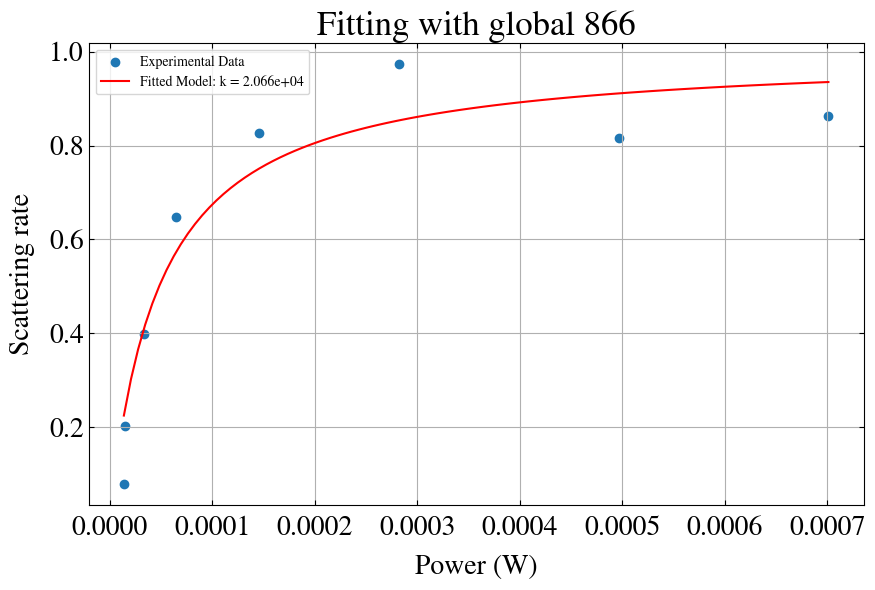

20662.515740484847

In [49]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Define the model function R = R0 * (S / (S + 1)) where S = k * I
def model(I, R0, k):
    S = k * I
    return R0 * (S / (S + 1))

# Data provided
data = np.array([
    [701e-6, 360.2334],
    [497e-6, 341.04172],
    [282e-6, 407.2334],
    [146e-6, 345.46655],
    [65e-6, 270.65836],
    [34e-6, 166.04164],
    [15e-6, 84.23334],
    [14e-6, 33.041668]
])

# Splitting data into intensity (I) and response (R)
I, R = data[:, 0], data[:, 1]

# Curve fitting
popt, pcov = curve_fit(model, I, R)
R0, k = popt

# Generating model data for plotting
I_model = np.linspace(I.min(), I.max(), 100)
R_model = model(I_model, R0, k)

# Plotting the original data and the fitted model
plt.figure(figsize=(10, 6))
plt.scatter(I, R / R0, label='Experimental Data')
plt.plot(I_model, R_model / R0, color='red', label=f'Fitted Model: k = {k:.3e}')
plt.title('Fitting with global 866', fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Power (W)')
plt.ylabel('Scattering rate')
plt.legend()
plt.grid(True)
plt.show()

# Returning the fitted parameter k
k

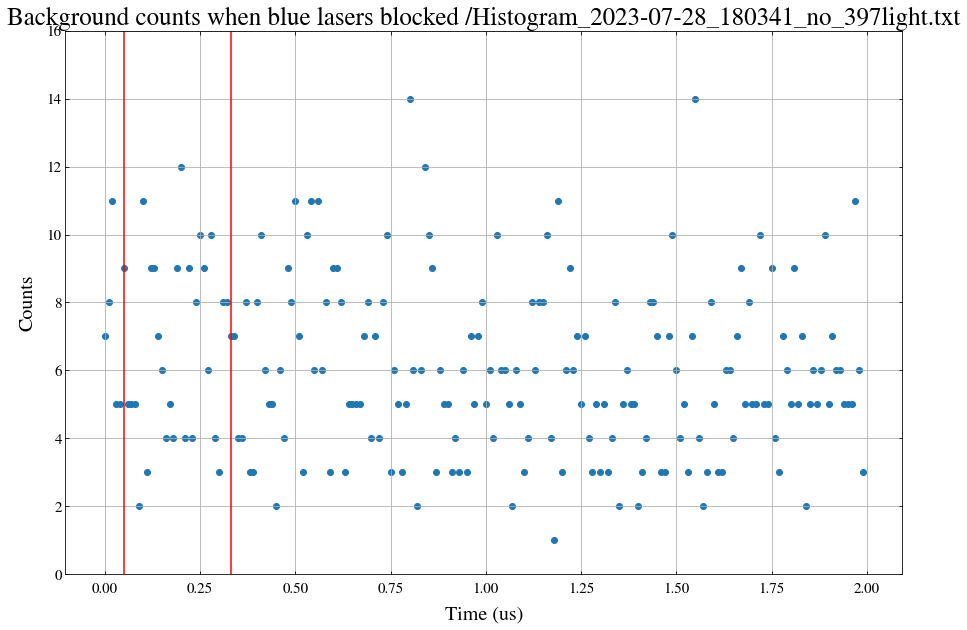

In [3]:
pure_background_path = "C:/Users/lattice/Desktop/TimeTagger Data/20230728"
file_name = "/Histogram_2023-07-28_180341_no_397light.txt"
pure_background_raw_data = np.loadtxt(pure_background_path+file_name, \
                        delimiter='\t', dtype='str')
pure_background_data = np.array(pure_background_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
pure_background_time_bins = pure_background_data[0, :] / 1e6
pure_background_counts = pure_background_data[1, :]
pure_background_counts_sum = np.sum(pure_background_counts[start_point:end_point])
pure_background_title = "Background counts when blue lasers blocked " + file_name

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(pure_background_time_bins, pure_background_counts, c='C0')
plt.axvline(pure_background_time_bins[start_point], color='r')
plt.axvline(pure_background_time_bins[end_point], color='r')
plt.title(pure_background_title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(pure_background_counts) + 2)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig('./pure_background_data.jpg')
plt.show()

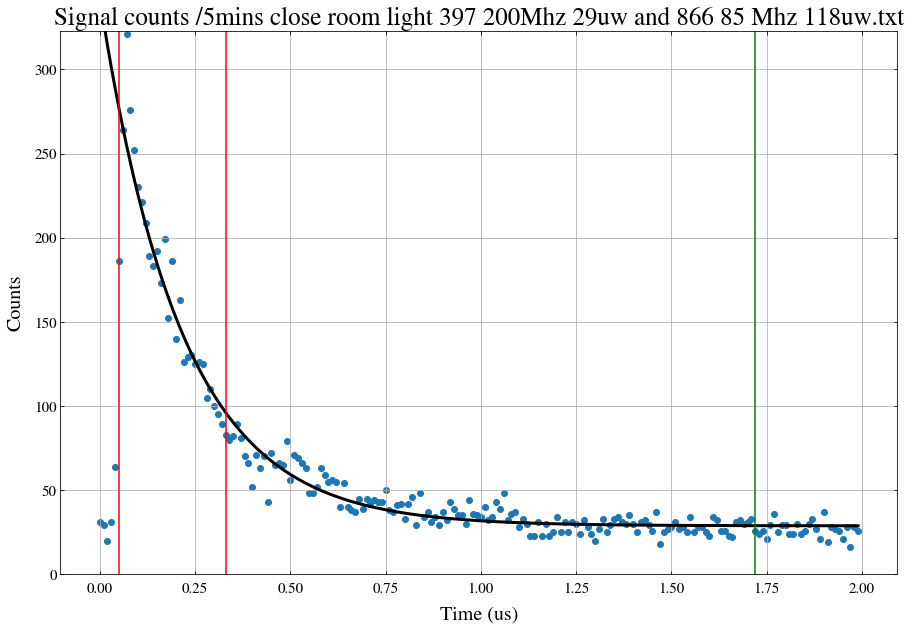

The signal to noise ratio is (5 mins):  4.370661
The dummy_SNR is (5 mins):  5.481081
The fitted_SNR is (5 mins):  4.82007216320255


In [4]:
signal_path = "C:/Users/lattice/Desktop/TimeTagger Data/20230728"
file_name = "/5mins close room light 397 200Mhz 29uw and 866 85 Mhz 118uw.txt"
signal_raw_data = np.loadtxt(pure_background_path+file_name, \
                        delimiter='\t', dtype='str')
signal_data = np.array(signal_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
signal_time_bins = signal_data[0, :] / 1e6
signal_counts = signal_data[1, :]
signal_counts_sum = np.sum(signal_counts[start_point:end_point])
signal_title = "Signal counts " + file_name

def func(x, a, b, c):
    return (a * np.exp(b * x) + c)
params, params_covariance = curve_fit(func, signal_time_bins[start_point:], signal_counts[start_point:], \
                                      p0=[126.40328917,  -2.48033265,  29.73986418])
fit_signal_counts = func(signal_time_bins, params[0], params[1], params[2])

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(signal_time_bins, signal_counts, c='C0')
plt.plot(signal_time_bins, fit_signal_counts, c='black', linewidth = 3)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')
plt.axvline(signal_time_bins[len(signal_counts) - (end_point - start_point)], color='g')
plt.title(signal_title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(signal_counts) + 2)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig('./signal_data.jpg')
plt.show()

signal_to_noise_ratio = (signal_counts_sum - background_counts_sum) / background_counts_sum
print("The signal to noise ratio is (5 mins): ", signal_to_noise_ratio)

dummy_SNR = (np.sum(signal_counts[start_point:end_point]) - np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])) \
          / (np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("The dummy_SNR is (5 mins): ", dummy_SNR)

result1, error1 = quad(lambda x: func(x, params[0], params[1], params[2]), signal_time_bins[start_point], signal_time_bins[end_point])
result2, error2 = quad(lambda x: params[2], signal_time_bins[start_point], signal_time_bins[end_point])
fitted_SNR = (result1 - result2) / result2
print("The fitted_SNR is (5 mins): ", fitted_SNR)

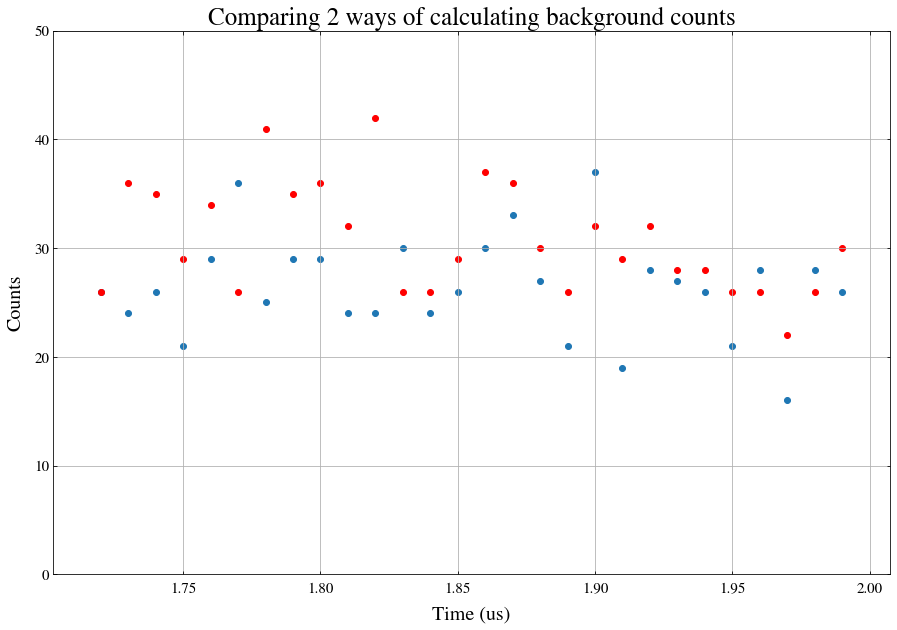

np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]) =  740.0
np.sum(background_counts[start_point:end_point]) =  893.0


In [5]:
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(signal_time_bins[(len(signal_counts) - (end_point - start_point)):], \
            signal_counts[(len(signal_counts) - (end_point - start_point)):], c='C0')
plt.scatter(background_time_bins[(len(signal_counts) - (end_point - start_point)):], \
            background_counts[(len(signal_counts) - (end_point - start_point)):], c='r')
plt.title("Comparing 2 ways of calculating background counts", fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(signal_counts[(len(signal_counts) // 2):]) + 2)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig('./signal_data.jpg')
plt.show()

print("np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]) = ", \
       np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("np.sum(background_counts[start_point:end_point]) = ", \
       np.sum(background_counts[start_point:end_point]))

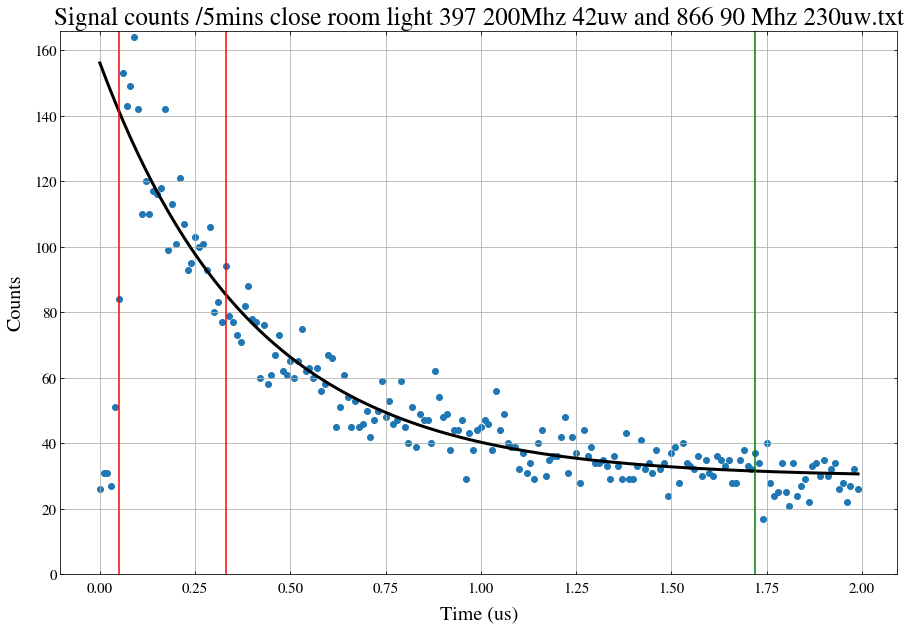

The dummy_SNR is (5 mins):  2.8765433
The fitted_SNR is (5 mins):  2.7067389085856557


In [6]:
signal_path = "C:/Users/lattice/Desktop/TimeTagger Data/20230728"
file_name = "/5mins close room light 397 200Mhz 42uw and 866 90 Mhz 230uw.txt"
signal_raw_data = np.loadtxt(pure_background_path+file_name, \
                        delimiter='\t', dtype='str')
signal_data = np.array(signal_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
signal_time_bins = signal_data[0, :] / 1e6
signal_counts = signal_data[1, :]
signal_counts_sum = np.sum(signal_counts[start_point:end_point])
signal_title = "Signal counts " + file_name

def func(x, a, b, c):
    return (a * np.exp(b * x) + c)
params, params_covariance = curve_fit(func, signal_time_bins[start_point:], signal_counts[start_point:], \
                                      p0=[126.40328917,  -2.48033265,  29.73986418])
fit_signal_counts = func(signal_time_bins, params[0], params[1], params[2])

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(signal_time_bins, signal_counts, c='C0')
plt.plot(signal_time_bins, fit_signal_counts, c='black', linewidth = 3)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')
plt.axvline(signal_time_bins[len(signal_counts) - (end_point - start_point)], color='g')
plt.title(signal_title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(signal_counts) + 2)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig('./signal_data.jpg')
plt.show()

dummy_SNR = (np.sum(signal_counts[start_point:end_point]) - np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])) \
          / (np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("The dummy_SNR is (5 mins): ", dummy_SNR)

result1, error1 = quad(lambda x: func(x, params[0], params[1], params[2]), signal_time_bins[start_point], signal_time_bins[end_point])
result2, error2 = quad(lambda x: params[2], signal_time_bins[start_point], signal_time_bins[end_point])
fitted_SNR = (result1 - result2) / result2
print("The fitted_SNR is (5 mins): ", fitted_SNR)

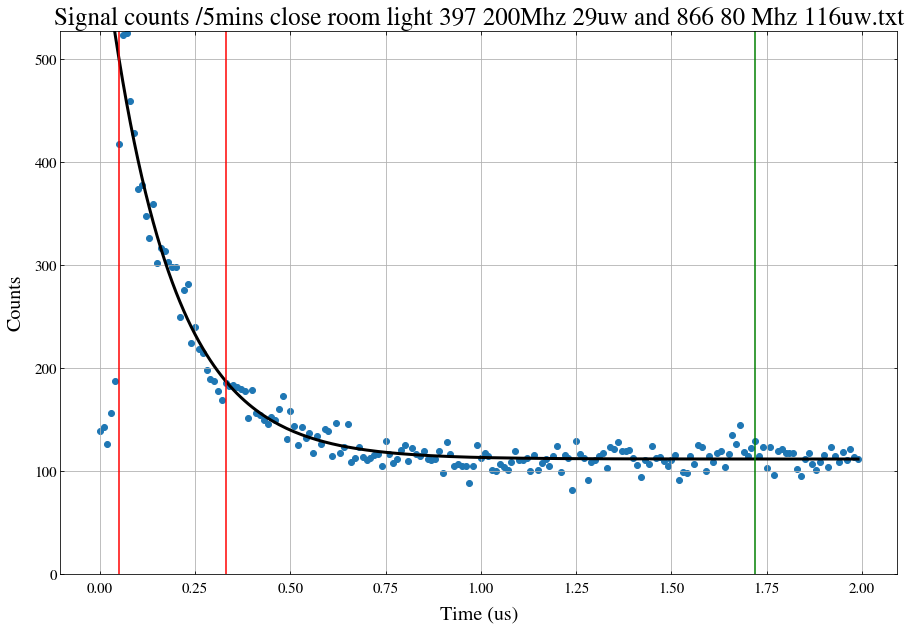

The dummy_SNR is (5 mins):  1.7088448
The fitted_SNR is (5 mins):  1.7111685711451545


In [7]:
signal_path = "C:/Users/lattice/Desktop/TimeTagger Data/20230728"
file_name = "/5mins close room light 397 200Mhz 29uw and 866 80 Mhz 116uw.txt"
signal_raw_data = np.loadtxt(pure_background_path+file_name, \
                        delimiter='\t', dtype='str')
signal_data = np.array(signal_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
signal_time_bins = signal_data[0, :] / 1e6
signal_counts = signal_data[1, :]
signal_counts_sum = np.sum(signal_counts)
signal_title = "Signal counts " + file_name

def func(x, a, b, c):
    return (a * np.exp(b * x) + c)
params, params_covariance = curve_fit(func, signal_time_bins[start_point:], signal_counts[start_point:], \
                                      p0=[126.40328917,  -2.48033265,  29.73986418])
fit_signal_counts = func(signal_time_bins, params[0], params[1], params[2])

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(signal_time_bins, signal_counts, c='C0')
plt.plot(signal_time_bins, fit_signal_counts, c='black', linewidth = 3)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')
plt.axvline(signal_time_bins[len(signal_counts) - (end_point - start_point)], color='g')
plt.title(signal_title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(signal_counts) + 2)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig('./signal_data.jpg')
plt.show()

dummy_SNR = (np.sum(signal_counts[start_point:end_point]) - np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])) \
          / (np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("The dummy_SNR is (5 mins): ", dummy_SNR)

result1, error1 = quad(lambda x: func(x, params[0], params[1], params[2]), signal_time_bins[start_point], signal_time_bins[end_point])
result2, error2 = quad(lambda x: params[2], signal_time_bins[start_point], signal_time_bins[end_point])
fitted_SNR = (result1 - result2) / result2
print("The fitted_SNR is (5 mins): ", fitted_SNR)

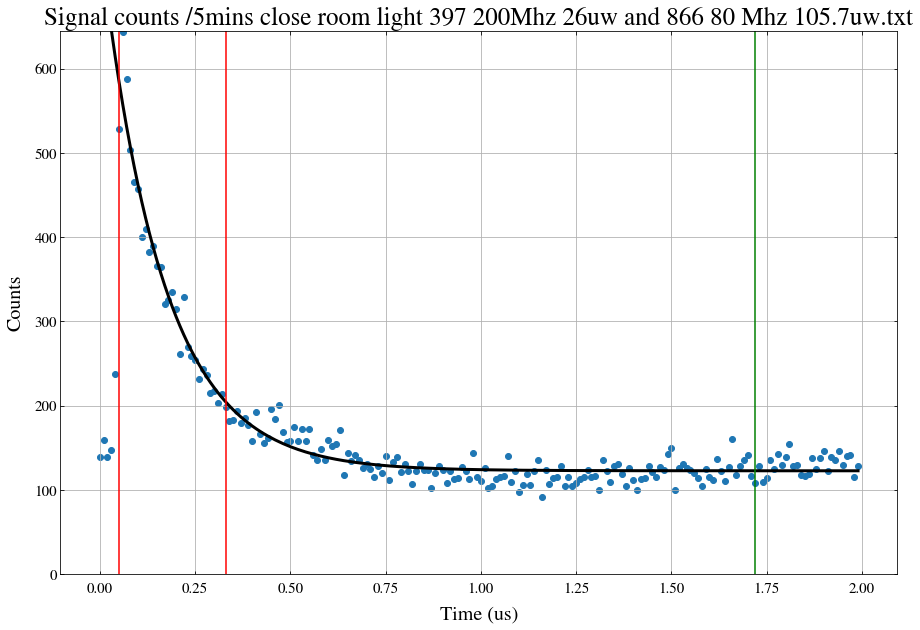

The dummy_SNR is (5 mins):  1.6704171
The fitted_SNR is (5 mins):  1.7903974120176027


In [11]:
signal_path = "C:/Users/lattice/Desktop/TimeTagger Data/20230728"
file_name = "/5mins close room light 397 200Mhz 26uw and 866 80 Mhz 105.7uw.txt"
signal_raw_data = np.loadtxt(pure_background_path+file_name, \
                        delimiter='\t', dtype='str')
signal_data = np.array(signal_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
signal_time_bins = signal_data[0, :] / 1e6
signal_counts = signal_data[1, :]
signal_counts_sum = np.sum(signal_counts)
signal_title = "Signal counts " + file_name

def func(x, a, b, c):
    return (a * np.exp(b * x) + c)
params, params_covariance = curve_fit(func, signal_time_bins[start_point:], signal_counts[start_point:], \
                                      p0=[126.40328917,  -2.48033265,  29.73986418])
fit_signal_counts = func(signal_time_bins, params[0], params[1], params[2])

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(signal_time_bins, signal_counts, c='C0')
plt.plot(signal_time_bins, fit_signal_counts, c='black', linewidth = 3)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')
plt.axvline(signal_time_bins[len(signal_counts) - (end_point - start_point)], color='g')
plt.title(signal_title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(signal_counts) + 2)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig('./signal_data.jpg')
plt.show()

dummy_SNR = (np.sum(signal_counts[start_point:end_point]) - np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])) \
          / (np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("The dummy_SNR is (5 mins): ", dummy_SNR)

result1, error1 = quad(lambda x: func(x, params[0], params[1], params[2]), signal_time_bins[start_point], signal_time_bins[end_point])
result2, error2 = quad(lambda x: params[2], signal_time_bins[start_point], signal_time_bins[end_point])
fitted_SNR = (result1 - result2) / result2
print("The fitted_SNR is (5 mins): ", fitted_SNR)

The dummy_SNR is (2 mins):  0.19614463
The fitted_SNR is (2 mins):  0.27312529954132103


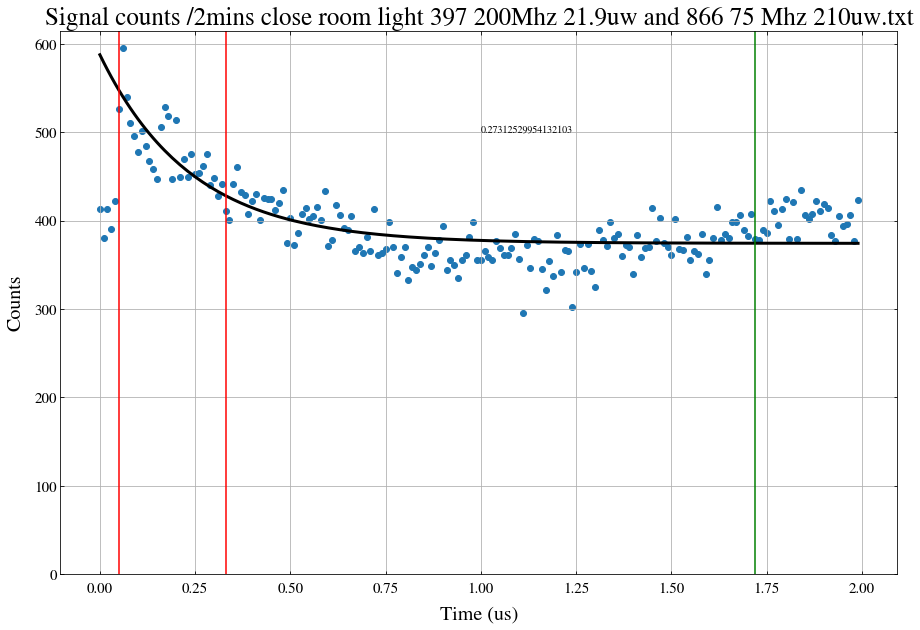

In [29]:
#2023.07.31

signal_path = "C:/Users/lattice/Desktop/TimeTagger Data/20230731"
file_name = "/2mins close room light 397 200Mhz 21.9uw and 866 75 Mhz 210uw.txt"
signal_raw_data = np.loadtxt(signal_path+file_name, \
                        delimiter='\t', dtype='str')
signal_data = np.array(signal_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
signal_time_bins = signal_data[0, :] / 1e6
signal_counts = signal_data[1, :]
signal_counts_sum = np.sum(signal_counts)
signal_title = "Signal counts " + file_name

def func(x, a, b, c):
    return (a * np.exp(b * x) + c)
params, params_covariance = curve_fit(func, signal_time_bins[start_point:], signal_counts[start_point:], \
                                      p0=[126.40328917,  -2.48033265,  29.73986418])
fit_signal_counts = func(signal_time_bins, params[0], params[1], params[2])

dummy_SNR = (np.sum(signal_counts[start_point:end_point]) - np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])) \
          / (np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("The dummy_SNR is (2 mins): ", dummy_SNR)

result1, error1 = quad(lambda x: func(x, params[0], params[1], params[2]), signal_time_bins[start_point], signal_time_bins[end_point])
result2, error2 = quad(lambda x: params[2], signal_time_bins[start_point], signal_time_bins[end_point])
fitted_SNR = (result1 - result2) / result2
print("The fitted_SNR is (2 mins): ", fitted_SNR)

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(signal_time_bins, signal_counts, c='C0')
plt.plot(signal_time_bins, fit_signal_counts, c='black', linewidth = 3)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')
plt.axvline(signal_time_bins[len(signal_counts) - (end_point - start_point)], color='g')
plt.annotate(fitted_SNR, xy=(1,500))
plt.title(signal_title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(signal_counts) + 20)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig('./'+file_name+'.jpg')
plt.show()

The dummy_SNR is (2 mins):  35.0
The fitted_SNR is (2 mins):  35.253778485929104


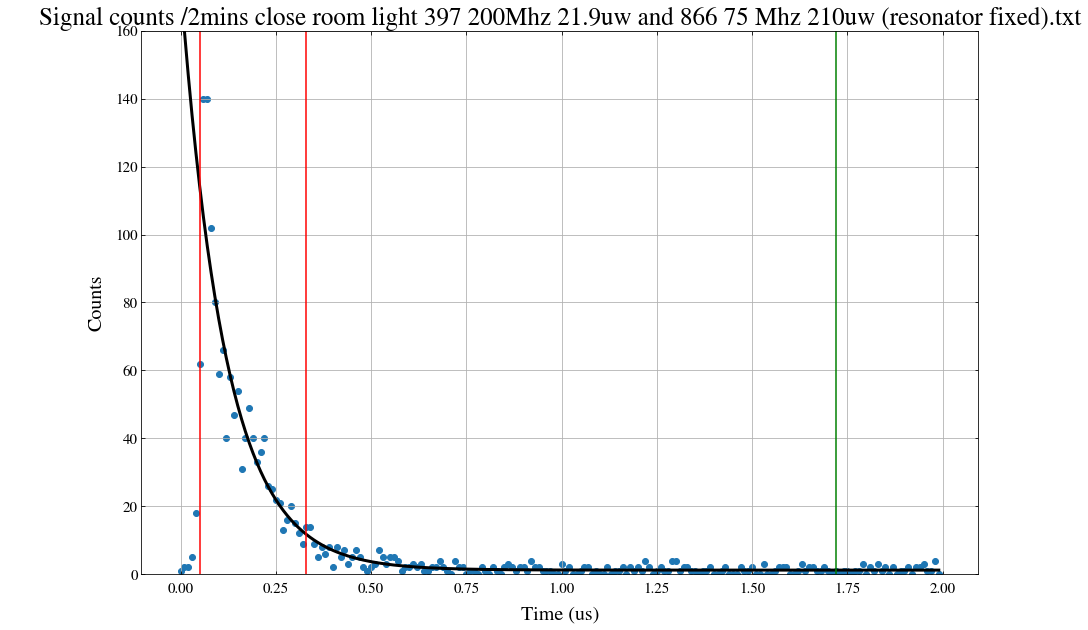

In [36]:
#2023.07.31

signal_path = "C:/Users/lattice/Desktop/TimeTagger Data/20230731"
file_name = "/2mins close room light 397 200Mhz 21.9uw and 866 75 Mhz 210uw (resonator fixed).txt"
signal_raw_data = np.loadtxt(signal_path+file_name, \
                        delimiter='\t', dtype='str')
signal_data = np.array(signal_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
signal_time_bins = signal_data[0, :] / 1e6
signal_counts = signal_data[1, :]
signal_counts_sum = np.sum(signal_counts)
signal_title = "Signal counts " + file_name

def func(x, a, b, c):
    return (a * np.exp(b * x) + c)
params, params_covariance = curve_fit(func, signal_time_bins[start_point:], signal_counts[start_point:], \
                                      p0=[126.40328917,  -2.48033265,  29.73986418])
fit_signal_counts = func(signal_time_bins, params[0], params[1], params[2])
bright_window_counts = np.sum(signal_counts[start_point:end_point])
dark_window_counts = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])
dummy_SNR = (np.sum(signal_counts[start_point:end_point]) - np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])) \
          / (np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("The dummy_SNR is (2 mins): ", dummy_SNR)

result1, error1 = quad(lambda x: func(x, params[0], params[1], params[2]), signal_time_bins[start_point], signal_time_bins[end_point])
result2, error2 = quad(lambda x: params[2], signal_time_bins[start_point], signal_time_bins[end_point])
fitted_SNR = (result1 - result2) / result2
print("The fitted_SNR is (2 mins): ", fitted_SNR)

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(signal_time_bins, signal_counts, c='C0')
plt.plot(signal_time_bins, fit_signal_counts, c='black', linewidth = 3)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')
plt.axvline(signal_time_bins[len(signal_counts) - (end_point - start_point)], color='g')
plt.annotate(fitted_SNR, xy=(1,500))
plt.title(signal_title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(signal_counts) + 20)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig('./'+file_name+'.jpg')
plt.show()

In [33]:
result2

0.34273579131073617

In [35]:
np.sum(signal_counts[start_point:end_point])
np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])

36.0

bright_window_counts =  7.725
The dummy_SNR is (2 mins):  91.7
The fitted_SNR is (2 mins):  138.87446445275532


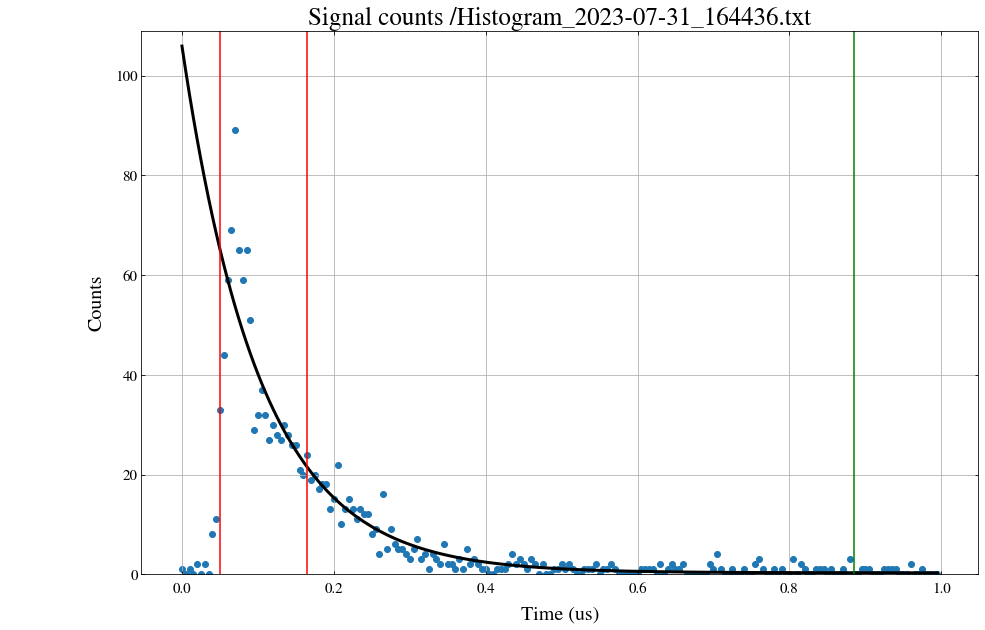

In [11]:
#2023.07.31

length = len(background_raw_data)
start_point = 10 #first five points are not good
end_point = length // 6

signal_path = "C:/Users/lattice/Desktop/TimeTagger Data/20230731"
file_name = "/Histogram_2023-07-31_164436.txt"
signal_raw_data = np.loadtxt(signal_path+file_name, \
                        delimiter='\t', dtype='str')
signal_data = np.array(signal_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
signal_time_bins = signal_data[0, :] / 1e6
signal_counts = signal_data[1, :]
signal_counts_sum = np.sum(signal_counts)
signal_title = "Signal counts " + file_name

def func(x, a, b, c):
    return (a * np.exp(b * x) + c)
params, params_covariance = curve_fit(func, signal_time_bins[start_point:], signal_counts[start_point:], \
                                      p0=[126.40328917,  -2.48033265,  29.73986418])
fit_signal_counts = func(signal_time_bins, params[0], params[1], params[2])
bright_window_counts = np.sum(signal_counts[start_point:end_point])
print("bright_window_counts = ", bright_window_counts / 120)

dark_window_counts = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])
dummy_SNR = (np.sum(signal_counts[start_point:end_point]) - np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])) \
          / (np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("The dummy_SNR is (2 mins): ", dummy_SNR)

result1, error1 = quad(lambda x: func(x, *params), signal_time_bins[start_point], signal_time_bins[end_point])
result2, error2 = quad(lambda x: params[2], signal_time_bins[start_point], signal_time_bins[end_point])
fitted_SNR = (result1 - result2) / result2
print("The fitted_SNR is (2 mins): ", fitted_SNR)

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(signal_time_bins, signal_counts, c='C0')
plt.plot(signal_time_bins, fit_signal_counts, c='black', linewidth = 3)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')
plt.axvline(signal_time_bins[len(signal_counts) - (end_point - start_point)], color='g')
plt.annotate(fitted_SNR, xy=(1,500))
plt.title(signal_title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(signal_counts) + 20)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig('./'+file_name+'data_analysis '+'.jpg')
plt.show()

findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: F

bright_window_counts =  8.8
The dummy_SNR is (2 mins):  69.4


findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: Font family 'Cambria' not found.
findfont: F

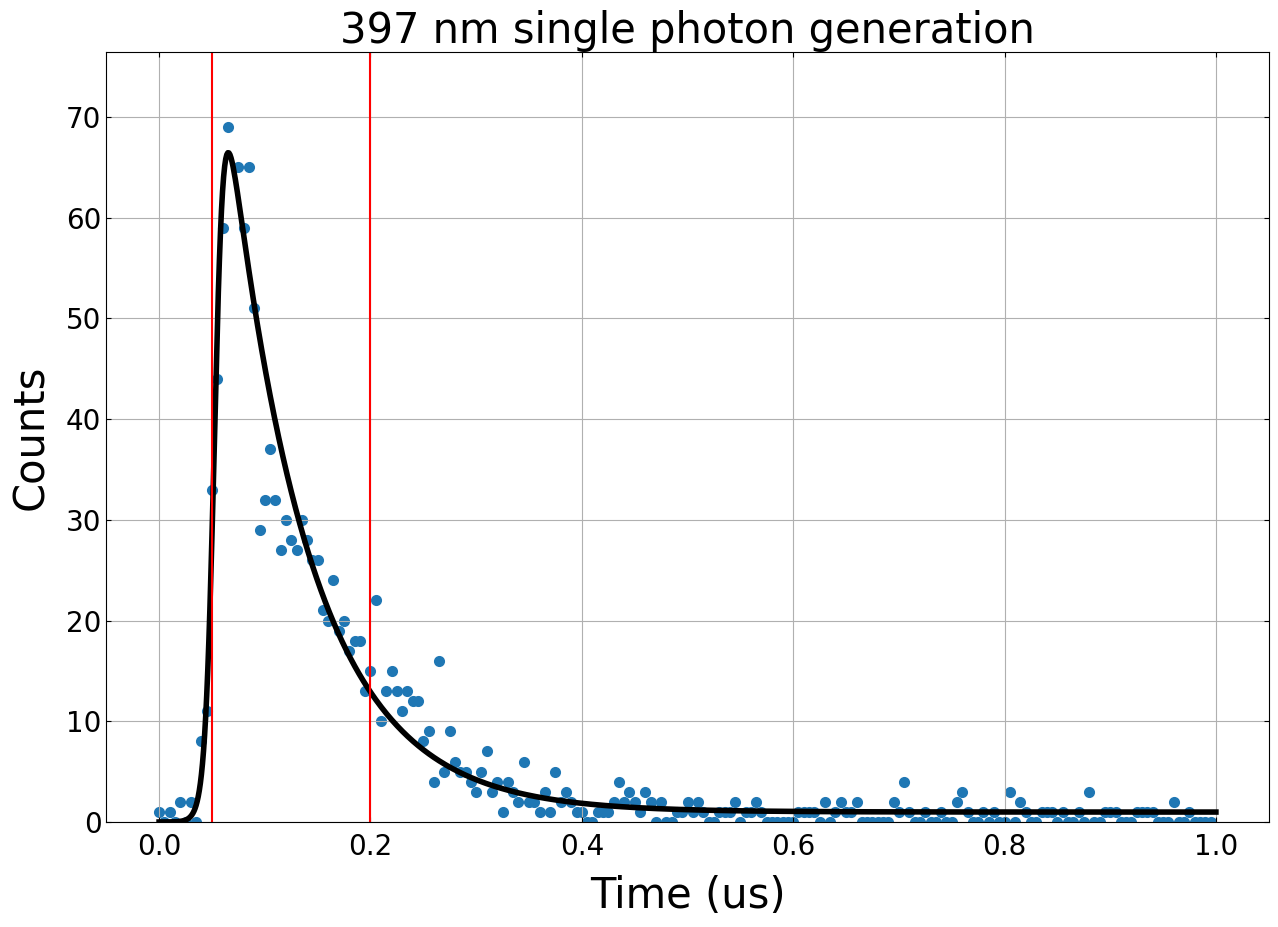

In [9]:
#2023.07.31

length = 201
start_point = 10 #first five points are not good
end_point = length // 5

signal_path = ""
file_name = "Histogram_2023-07-31_164436.txt"
signal_raw_data = np.loadtxt(signal_path+file_name, \
                        delimiter='\t', dtype='str')
signal_data = np.array(signal_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
signal_time_bins = signal_data[0, :] / 1e6
signal_counts = signal_data[1, :]
signal_counts_sum = np.sum(signal_counts)
signal_title = "Signal counts " + file_name

p0=[126.40328917,  -2.48033265,  29.73986418, 0.17, 0.25, 100, 0.03]
p0=[189.47, -13.1, 1.14, 0.217, 0.253, 227.7, 0.047]
def func(x, a, b, c, d, e, f, k):
    return (a * np.exp(b * x) + c) * (d) / (e + np.exp(-f * (x - k)))
def func_test(x, a, b, c, d, e, f, k):
    return (d) / (e + np.exp(-f * (x - k)))
params, params_covariance = curve_fit(func, signal_time_bins[start_point:], signal_counts[start_point:], \
                                      p0=p0)
test_bins = np.linspace(-0.00003,1,1000)
fit_signal_counts = func(test_bins, *params)
# test = func_test(test_bins, *p0)
test = func(test_bins, *p0)
bright_window_counts = np.sum(signal_counts[start_point:end_point])
print("bright_window_counts = ", bright_window_counts / 120)

dark_window_counts = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])
dummy_SNR = (np.sum(signal_counts[start_point:end_point]) - np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])) \
          / (np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("The dummy_SNR is (2 mins): ", dummy_SNR)

'''plt.plot'''
plt.figure(figsize = (15, 10))

# Set font to Cambria
plt.rcParams['font.family'] = 'Cambria'

plt.scatter(signal_time_bins, signal_counts, c='C0', lw=2)
plt.plot(test_bins, fit_signal_counts, c='black', linewidth=4)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')

# Update fontdict to specify Cambria
plt.title("397 nm single photon generation", fontdict={'family': 'Cambria', 'size': 30})
plt.xlabel('Time (us)', fontdict={'family': 'Cambria', 'size': 30})
plt.ylabel('Counts', fontdict={'family': 'Cambria', 'size': 30})

plt.ylim(0, np.max(fit_signal_counts) + 10)

# Update fontproperties to specify Cambria
plt.yticks(fontproperties='Cambria', size=20)
plt.xticks(fontproperties='Cambria', size=20)

plt.grid(True)
plt.savefig('./' + file_name + 'data_analysis ' + '.jpg')
plt.show()

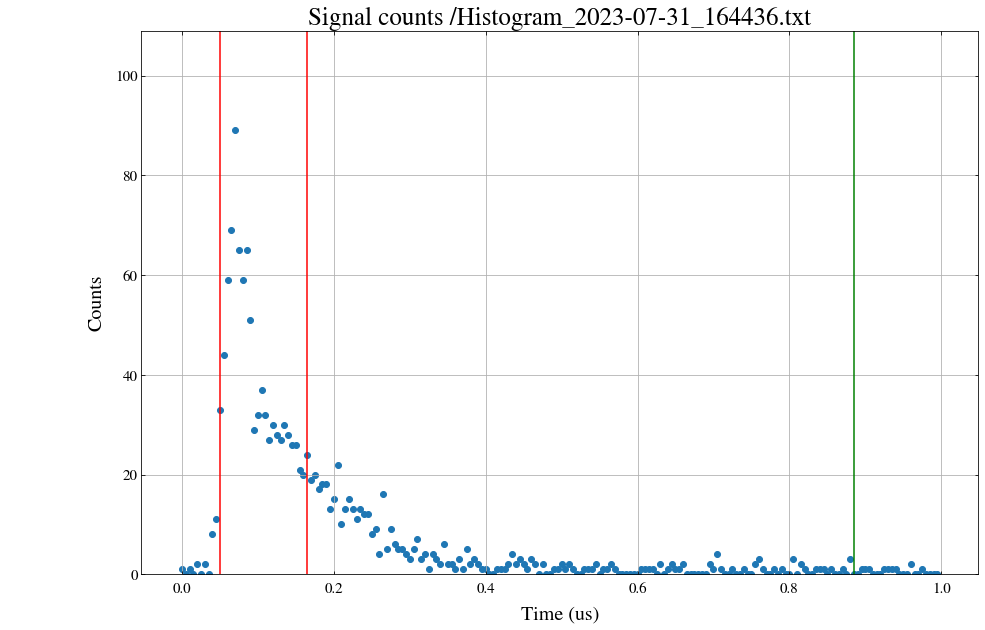

In [9]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import curve_fit

# ... (your existing code for loading data)

# Normalize the signal_counts to fit the Beta distribution
eps = 1e-5  # Small offset to ensure values are in the (0, 1) interval
normalized_counts = (signal_counts - np.min(signal_counts)) / (np.max(signal_counts) - np.min(signal_counts))
normalized_counts = eps + (1 - 2 * eps) * normalized_counts  # Rescale to be strictly between 0 and 1

# Fit the Beta distribution to the normalized_counts
alpha_est, _, beta_est, _ = stats.beta.fit(normalized_counts[start_point:end_point], floc=0, fscale=1)

# Generate fitted counts based on the Beta distribution
fitted_counts = stats.beta.pdf(normalized_counts, alpha_est, beta_est) * (np.max(signal_counts) - np.min(signal_counts)) + np.min(signal_counts)

# ... (your existing code for bright_window_counts, dark_window_counts, etc.)

# Update the plotting part
plt.figure(figsize = (15, 10))
plt.rc('font', family='STIXGeneral')
plt.scatter(signal_time_bins, signal_counts, c='C0')
plt.plot(signal_time_bins, fitted_counts, c='black', linewidth = 3)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')
plt.axvline(signal_time_bins[len(signal_counts) - (end_point - start_point)], color='g')
plt.annotate(fitted_SNR, xy=(1, 500))
plt.title(signal_title, fontdict={'family': 'STIXGeneral', 'size': 25})
plt.xlabel('Time (us)', fontdict={'family': 'STIXGeneral', 'size': 20})
plt.ylabel('Counts', fontdict={'family': 'STIXGeneral', 'size': 20})
plt.ylim(0, np.max(signal_counts) + 20)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig('./' + file_name + 'data_analysis ' + '.jpg')
plt.show()


In [8]:
normalized_counts

array([0.01123596, 0.        , 0.01123596, 0.        , 0.02247191,
       0.        , 0.02247191, 0.        , 0.08988764, 0.12359551,
       0.37078652, 0.49438202, 0.66292137, 0.7752809 , 1.        ,
       0.7303371 , 0.66292137, 0.7303371 , 0.5730337 , 0.3258427 ,
       0.35955057, 0.41573033, 0.35955057, 0.30337077, 0.33707866,
       0.31460676, 0.30337077, 0.33707866, 0.31460676, 0.29213482,
       0.29213482, 0.23595506, 0.2247191 , 0.26966292, 0.21348314,
       0.2247191 , 0.19101124, 0.20224719, 0.20224719, 0.14606741,
       0.16853933, 0.24719101, 0.11235955, 0.14606741, 0.16853933,
       0.14606741, 0.12359551, 0.14606741, 0.13483146, 0.13483146,
       0.08988764, 0.10112359, 0.04494382, 0.17977528, 0.05617978,
       0.10112359, 0.06741573, 0.05617978, 0.05617978, 0.04494382,
       0.03370786, 0.05617978, 0.07865169, 0.03370786, 0.04494382,
       0.01123596, 0.04494382, 0.03370786, 0.02247191, 0.06741573,
       0.02247191, 0.02247191, 0.01123596, 0.03370786, 0.01123

bright_window_counts =  13.108333333333333
The dummy_SNR is (2 mins):  97.3125
The fitted_SNR is (2 mins):  54.65240897951646
Total counts =  19.451449275362318
signal_to_noise_ratio =  16.693407960199004


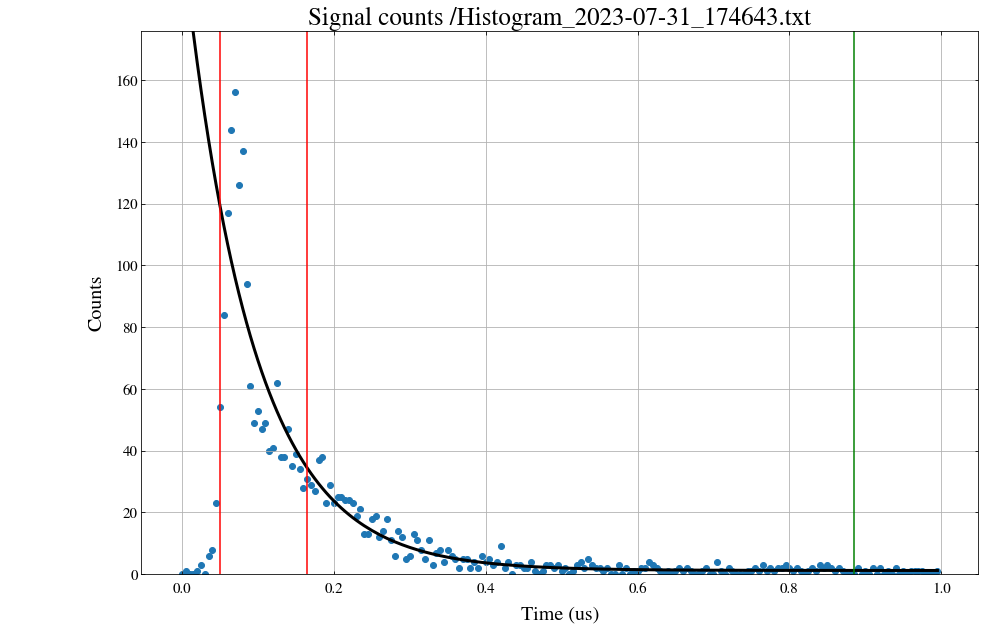

In [66]:
#2023.07.31

start_point = 10
end_point = length // 6

signal_path = "C:/Users/lattice/Desktop/TimeTagger Data/20230731"
file_name = "/Histogram_2023-07-31_174643.txt"
signal_raw_data = np.loadtxt(signal_path+file_name, \
                        delimiter='\t', dtype='str')
signal_data = np.array(signal_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
signal_time_bins = signal_data[0, :] / 1e6
signal_counts = signal_data[1, :]
signal_counts_sum = np.sum(signal_counts)
signal_title = "Signal counts " + file_name

def func(x, a, b, c):
    return (a * np.exp(b * x) + c)
params, params_covariance = curve_fit(func, signal_time_bins[start_point:], signal_counts[start_point:], \
                                      p0=[126.40328917,  -2.48033265,  29.73986418])
fit_signal_counts = func(signal_time_bins, params[0], params[1], params[2])
bright_window_counts = np.sum(signal_counts[start_point:end_point])
print("bright_window_counts = ", bright_window_counts / 120)

dark_window_counts = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])
dummy_SNR = (np.sum(signal_counts[start_point:end_point]) - np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])) \
          / (np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("The dummy_SNR is (2 mins): ", dummy_SNR)

result1, error1 = quad(lambda x: func(x, params[0], params[1], params[2]), signal_time_bins[start_point], signal_time_bins[end_point])
result2, error2 = quad(lambda x: params[2], signal_time_bins[start_point], signal_time_bins[end_point])
fitted_SNR = (result1 - result2) / result2
print("The fitted_SNR is (2 mins): ", fitted_SNR)

result1 = np.sum(signal_counts) #Total counts
result2 = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]) * (length) / (end_point - start_point)   #Noise counts
print("Total counts = ", (result1 - result2) / (120))   #Photon generation rate
print("signal_to_noise_ratio = ", (result1 - result2) / (result2))  #Total signal to noise ratio

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(signal_time_bins, signal_counts, c='C0')
plt.plot(signal_time_bins, fit_signal_counts, c='black', linewidth = 3)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')
plt.axvline(signal_time_bins[len(signal_counts) - (end_point - start_point)], color='g')
plt.annotate(fitted_SNR, xy=(1,500))
plt.title(signal_title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(signal_counts) + 20)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig('./'+file_name+'data_analysis '+'.jpg')
plt.show()

In [65]:
# start_point = 0
# end_point = -1
# result1, error1 = quad(lambda x: func(x, params[0], params[1], params[2]), signal_time_bins[start_point], signal_time_bins[end_point])
# result2, error2 = quad(lambda x: params[2], signal_time_bins[start_point], signal_time_bins[end_point])
# print("Total counts = ", result1 - result2)

result1 = np.sum(signal_counts)
result2 = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]) * (length) / (end_point - start_point)
print("Total counts = ", (result1 - result2) / (120))
print("signal_to_noise_ratio = ", (result1 - result2) / (result2))

Total counts =  19.451449275362318
signal_to_noise_ratio =  16.693407960199004


bright_window_counts = 17.791666666666668
The dummy_SNR is (2 mins): 40.862743
The fitted_SNR is (2 mins): 45.200212406733236
Total counts = 24.073958333333334 counts / s
Total signal_to_noise_ratio = 6.76353526485221


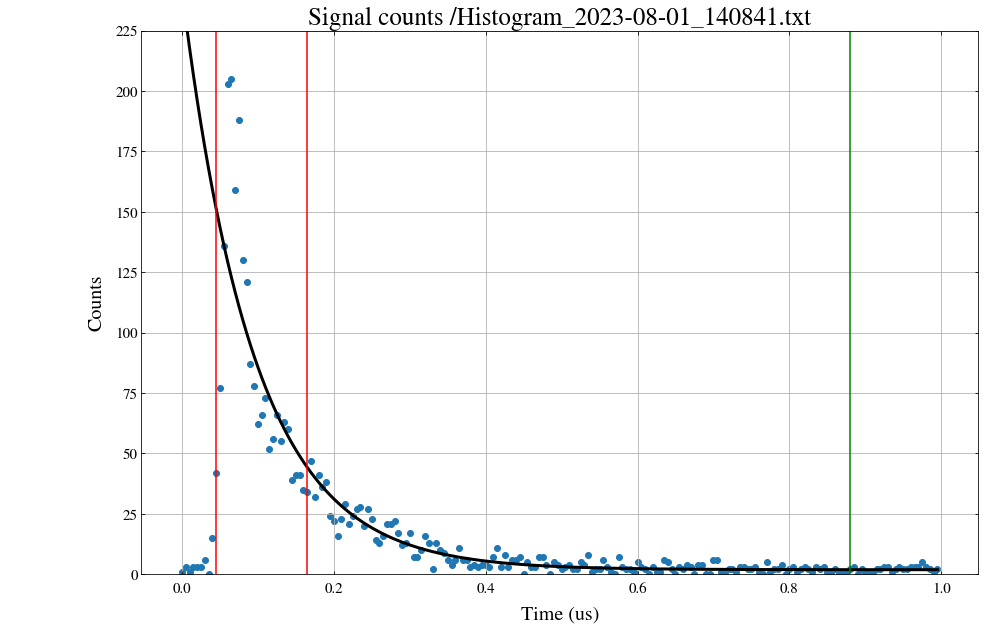

In [85]:
#2023.08.01

start_point = 9
end_point = length // 6

signal_path = "C:/Users/lattice/Desktop/TimeTagger Data/20230801"
file_name = "/Histogram_2023-08-01_140841.txt"
signal_raw_data = np.loadtxt(signal_path+file_name, \
                        delimiter='\t', dtype='str')
signal_data = np.array(signal_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
signal_time_bins = signal_data[0, :] / 1e6
signal_counts = signal_data[1, :]
signal_counts_sum = np.sum(signal_counts)
signal_title = "Signal counts " + file_name

def func(x, a, b, c):
    return (a * np.exp(b * x) + c)
params, params_covariance = curve_fit(func, signal_time_bins[start_point:], signal_counts[start_point:], \
                                      p0=[126.40328917,  -2.48033265,  29.73986418])
fit_signal_counts = func(signal_time_bins, params[0], params[1], params[2])
bright_window_counts = np.sum(signal_counts[start_point:end_point])
print("bright_window_counts =", bright_window_counts / 120)

dark_window_counts = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])
dummy_SNR = (np.sum(signal_counts[start_point:end_point]) - np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])) \
          / (np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("The dummy_SNR is (2 mins):", dummy_SNR)

result1, error1 = quad(lambda x: func(x, params[0], params[1], params[2]), signal_time_bins[start_point], signal_time_bins[end_point])
result2, error2 = quad(lambda x: params[2], signal_time_bins[start_point], signal_time_bins[end_point])
fitted_SNR = (result1 - result2) / result2
print("The fitted_SNR is (2 mins):", fitted_SNR)

result1 = np.sum(signal_counts) #Total counts
result2 = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]) * (length) / (end_point - start_point)   #Noise counts
print("Total counts =", (result1 - result2) / (120), "counts / s")   #Photon generation rate
print("Total signal_to_noise_ratio =", (result1 - result2) / (result2))  #Total signal to noise ratio

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(signal_time_bins, signal_counts, c='C0')
plt.plot(signal_time_bins, fit_signal_counts, c='black', linewidth = 3)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')
plt.axvline(signal_time_bins[len(signal_counts) - (end_point - start_point)], color='g')
plt.annotate(fitted_SNR, xy=(1,500))
plt.title(signal_title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(signal_counts) + 20)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig(signal_path+'/'+file_name+' data_analysis'+'.jpg')
plt.show()

bright_window_counts = 12.433333333333334
The dummy_SNR is (2 mins): 45.625
The fitted_SNR is (2 mins): 38.24767459060722
Total counts = 17.141666666666666 counts / s
Total signal_to_noise_ratio = 7.675373134328358


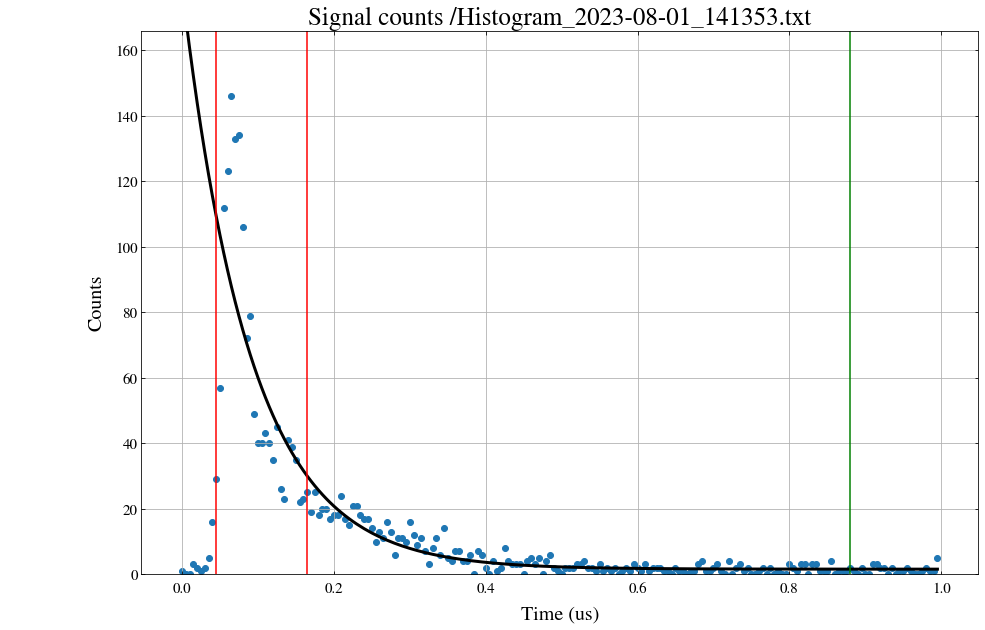

In [86]:
#2023.08.01

start_point = 9
end_point = length // 6

signal_path = "C:/Users/lattice/Desktop/TimeTagger Data/20230801"
file_name = "/Histogram_2023-08-01_141353.txt"
signal_raw_data = np.loadtxt(signal_path+file_name, \
                        delimiter='\t', dtype='str')
signal_data = np.array(signal_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
signal_time_bins = signal_data[0, :] / 1e6
signal_counts = signal_data[1, :]
signal_counts_sum = np.sum(signal_counts)
signal_title = "Signal counts " + file_name

def func(x, a, b, c):
    return (a * np.exp(b * x) + c)
params, params_covariance = curve_fit(func, signal_time_bins[start_point:], signal_counts[start_point:], \
                                      p0=[126.40328917,  -2.48033265,  29.73986418])
fit_signal_counts = func(signal_time_bins, params[0], params[1], params[2])
bright_window_counts = np.sum(signal_counts[start_point:end_point])
print("bright_window_counts =", bright_window_counts / 120)

dark_window_counts = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])
dummy_SNR = (np.sum(signal_counts[start_point:end_point]) - np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])) \
          / (np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("The dummy_SNR is (2 mins):", dummy_SNR)

result1, error1 = quad(lambda x: func(x, params[0], params[1], params[2]), signal_time_bins[start_point], signal_time_bins[end_point])
result2, error2 = quad(lambda x: params[2], signal_time_bins[start_point], signal_time_bins[end_point])
fitted_SNR = (result1 - result2) / result2
print("The fitted_SNR is (2 mins):", fitted_SNR)

result1 = np.sum(signal_counts) #Total counts
result2 = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]) * (length) / (end_point - start_point)   #Noise counts
print("Total counts =", (result1 - result2) / (120), "counts / s")   #Photon generation rate
print("Total signal_to_noise_ratio =", (result1 - result2) / (result2))  #Total signal to noise ratio

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(signal_time_bins, signal_counts, c='C0')
plt.plot(signal_time_bins, fit_signal_counts, c='black', linewidth = 3)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')
plt.axvline(signal_time_bins[len(signal_counts) - (end_point - start_point)], color='g')
plt.annotate(fitted_SNR, xy=(1,500))
plt.title(signal_title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(signal_counts) + 20)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig(signal_path+'/'+file_name+' data_analysis'+'.jpg')
plt.show()

bright_window_counts = 12.966666666666667
The dummy_SNR is (2 mins): 63.833332
The fitted_SNR is (2 mins): 68.97887973104497
Total counts = 18.616666666666667 counts / s
Total signal_to_noise_ratio = 11.114427860696518


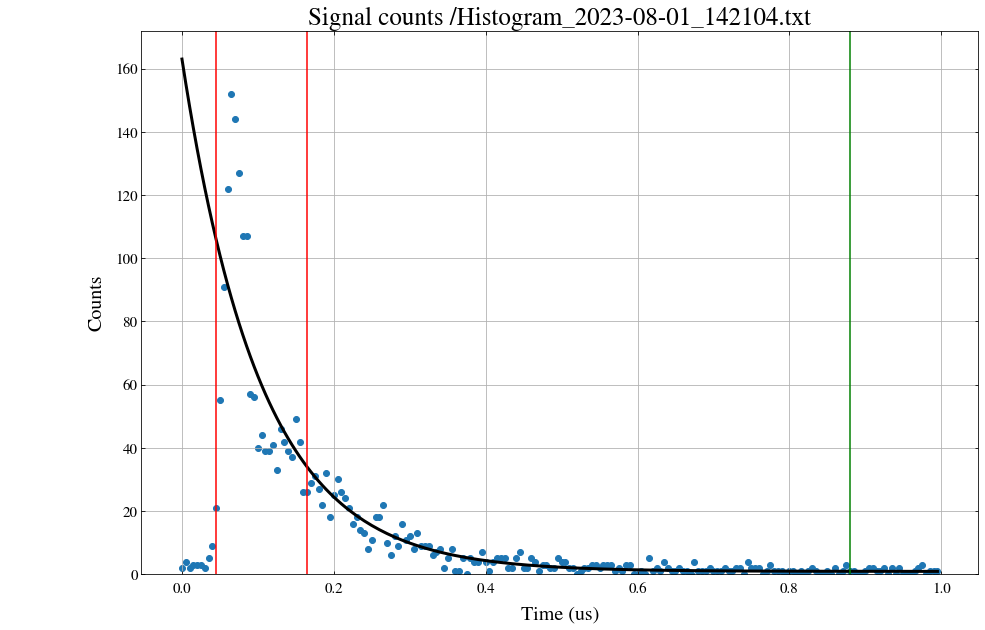

In [84]:
#2023.08.01

start_point = 9
end_point = length // 6

signal_path = "C:/Users/lattice/Desktop/TimeTagger Data/20230801"
file_name = "/Histogram_2023-08-01_142104.txt"
signal_raw_data = np.loadtxt(signal_path+file_name, \
                        delimiter='\t', dtype='str')
signal_data = np.array(signal_raw_data[1:]).astype(dtype="f").transpose() #.astype(dtype="f")
signal_time_bins = signal_data[0, :] / 1e6
signal_counts = signal_data[1, :]
signal_counts_sum = np.sum(signal_counts)
signal_title = "Signal counts " + file_name

def func(x, a, b, c):
    return (a * np.exp(b * x) + c)
params, params_covariance = curve_fit(func, signal_time_bins[start_point:], signal_counts[start_point:], \
                                      p0=[126.40328917,  -2.48033265,  29.73986418])
fit_signal_counts = func(signal_time_bins, params[0], params[1], params[2])
bright_window_counts = np.sum(signal_counts[start_point:end_point])
print("bright_window_counts =", bright_window_counts / 120)

dark_window_counts = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])
dummy_SNR = (np.sum(signal_counts[start_point:end_point]) - np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):])) \
          / (np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]))
print("The dummy_SNR is (2 mins):", dummy_SNR)

result1, error1 = quad(lambda x: func(x, params[0], params[1], params[2]), signal_time_bins[start_point], signal_time_bins[end_point])
result2, error2 = quad(lambda x: params[2], signal_time_bins[start_point], signal_time_bins[end_point])
fitted_SNR = (result1 - result2) / result2
print("The fitted_SNR is (2 mins):", fitted_SNR)

result1 = np.sum(signal_counts) #Total counts
result2 = np.sum(signal_counts[(len(signal_counts) - (end_point - start_point)):]) * (length) / (end_point - start_point)   #Noise counts
print("Total counts =", (result1 - result2) / (120), "counts / s")   #Photon generation rate
print("Total signal_to_noise_ratio =", (result1 - result2) / (result2))  #Total signal to noise ratio

'''plt.plot'''
plt.figure(figsize = (15, 10))
plt.rc('font',family='STIXGeneral')
plt.scatter(signal_time_bins, signal_counts, c='C0')
plt.plot(signal_time_bins, fit_signal_counts, c='black', linewidth = 3)
plt.axvline(signal_time_bins[start_point], color='r')
plt.axvline(signal_time_bins[end_point], color='r')
plt.axvline(signal_time_bins[len(signal_counts) - (end_point - start_point)], color='g')
plt.annotate(fitted_SNR, xy=(1,500))
plt.title(signal_title, fontdict={'family' : 'STIXGeneral', 'size':25})
plt.xlabel('Time (us)', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylabel('Counts', fontdict={'family' : 'STIXGeneral', 'size':20})
plt.ylim(0, np.max(signal_counts) + 20)
plt.yticks(fontproperties='STIXGeneral', size=15)
plt.xticks(fontproperties='STIXGeneral', size=15)
plt.grid(True)
plt.savefig(signal_path+'/'+file_name+' data_analysis'+'.jpg')
plt.show()